In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm

from matrix_processing_helpers import sparsify_global_percentile
from matrix_processing_helpers import sparsify_topk_rows
from matrix_processing_helpers import reorder
from matrix_processing_helpers import reorder_clustering

### Load

In [2]:
type = "age"
type_names = {"age": "age", "mets": "MetSCORE", "sex": "sex"}
colormaps = {'age': 'Reds', 'mets': 'Greens', 'sex': 'Blues'}

results = np.load(f"Results_TR/attention_rollout/rollout_results_single_{type}.npz")

with open(f"Results_TR/attention_rollout/attn_matrices_single_{type}.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

with open(f"Results_TR/attention_rollout/sorted_pairs_single_{type}.pkl", "rb") as f:
    sorted_pairs = pickle.load(f)

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

### Rollout

In [3]:
interactions = results['mean_interactions']
interactions_log = results['mean_interactions_log']
importance = results['mean_importance']
# interactions_sparse = sparsify_global_percentile(interactions, keep_diagonal=False)
# interactions_topk = sparsify_topk_rows(interactions, keep_diagonal=False)

#### Plot: top-k attention rollout

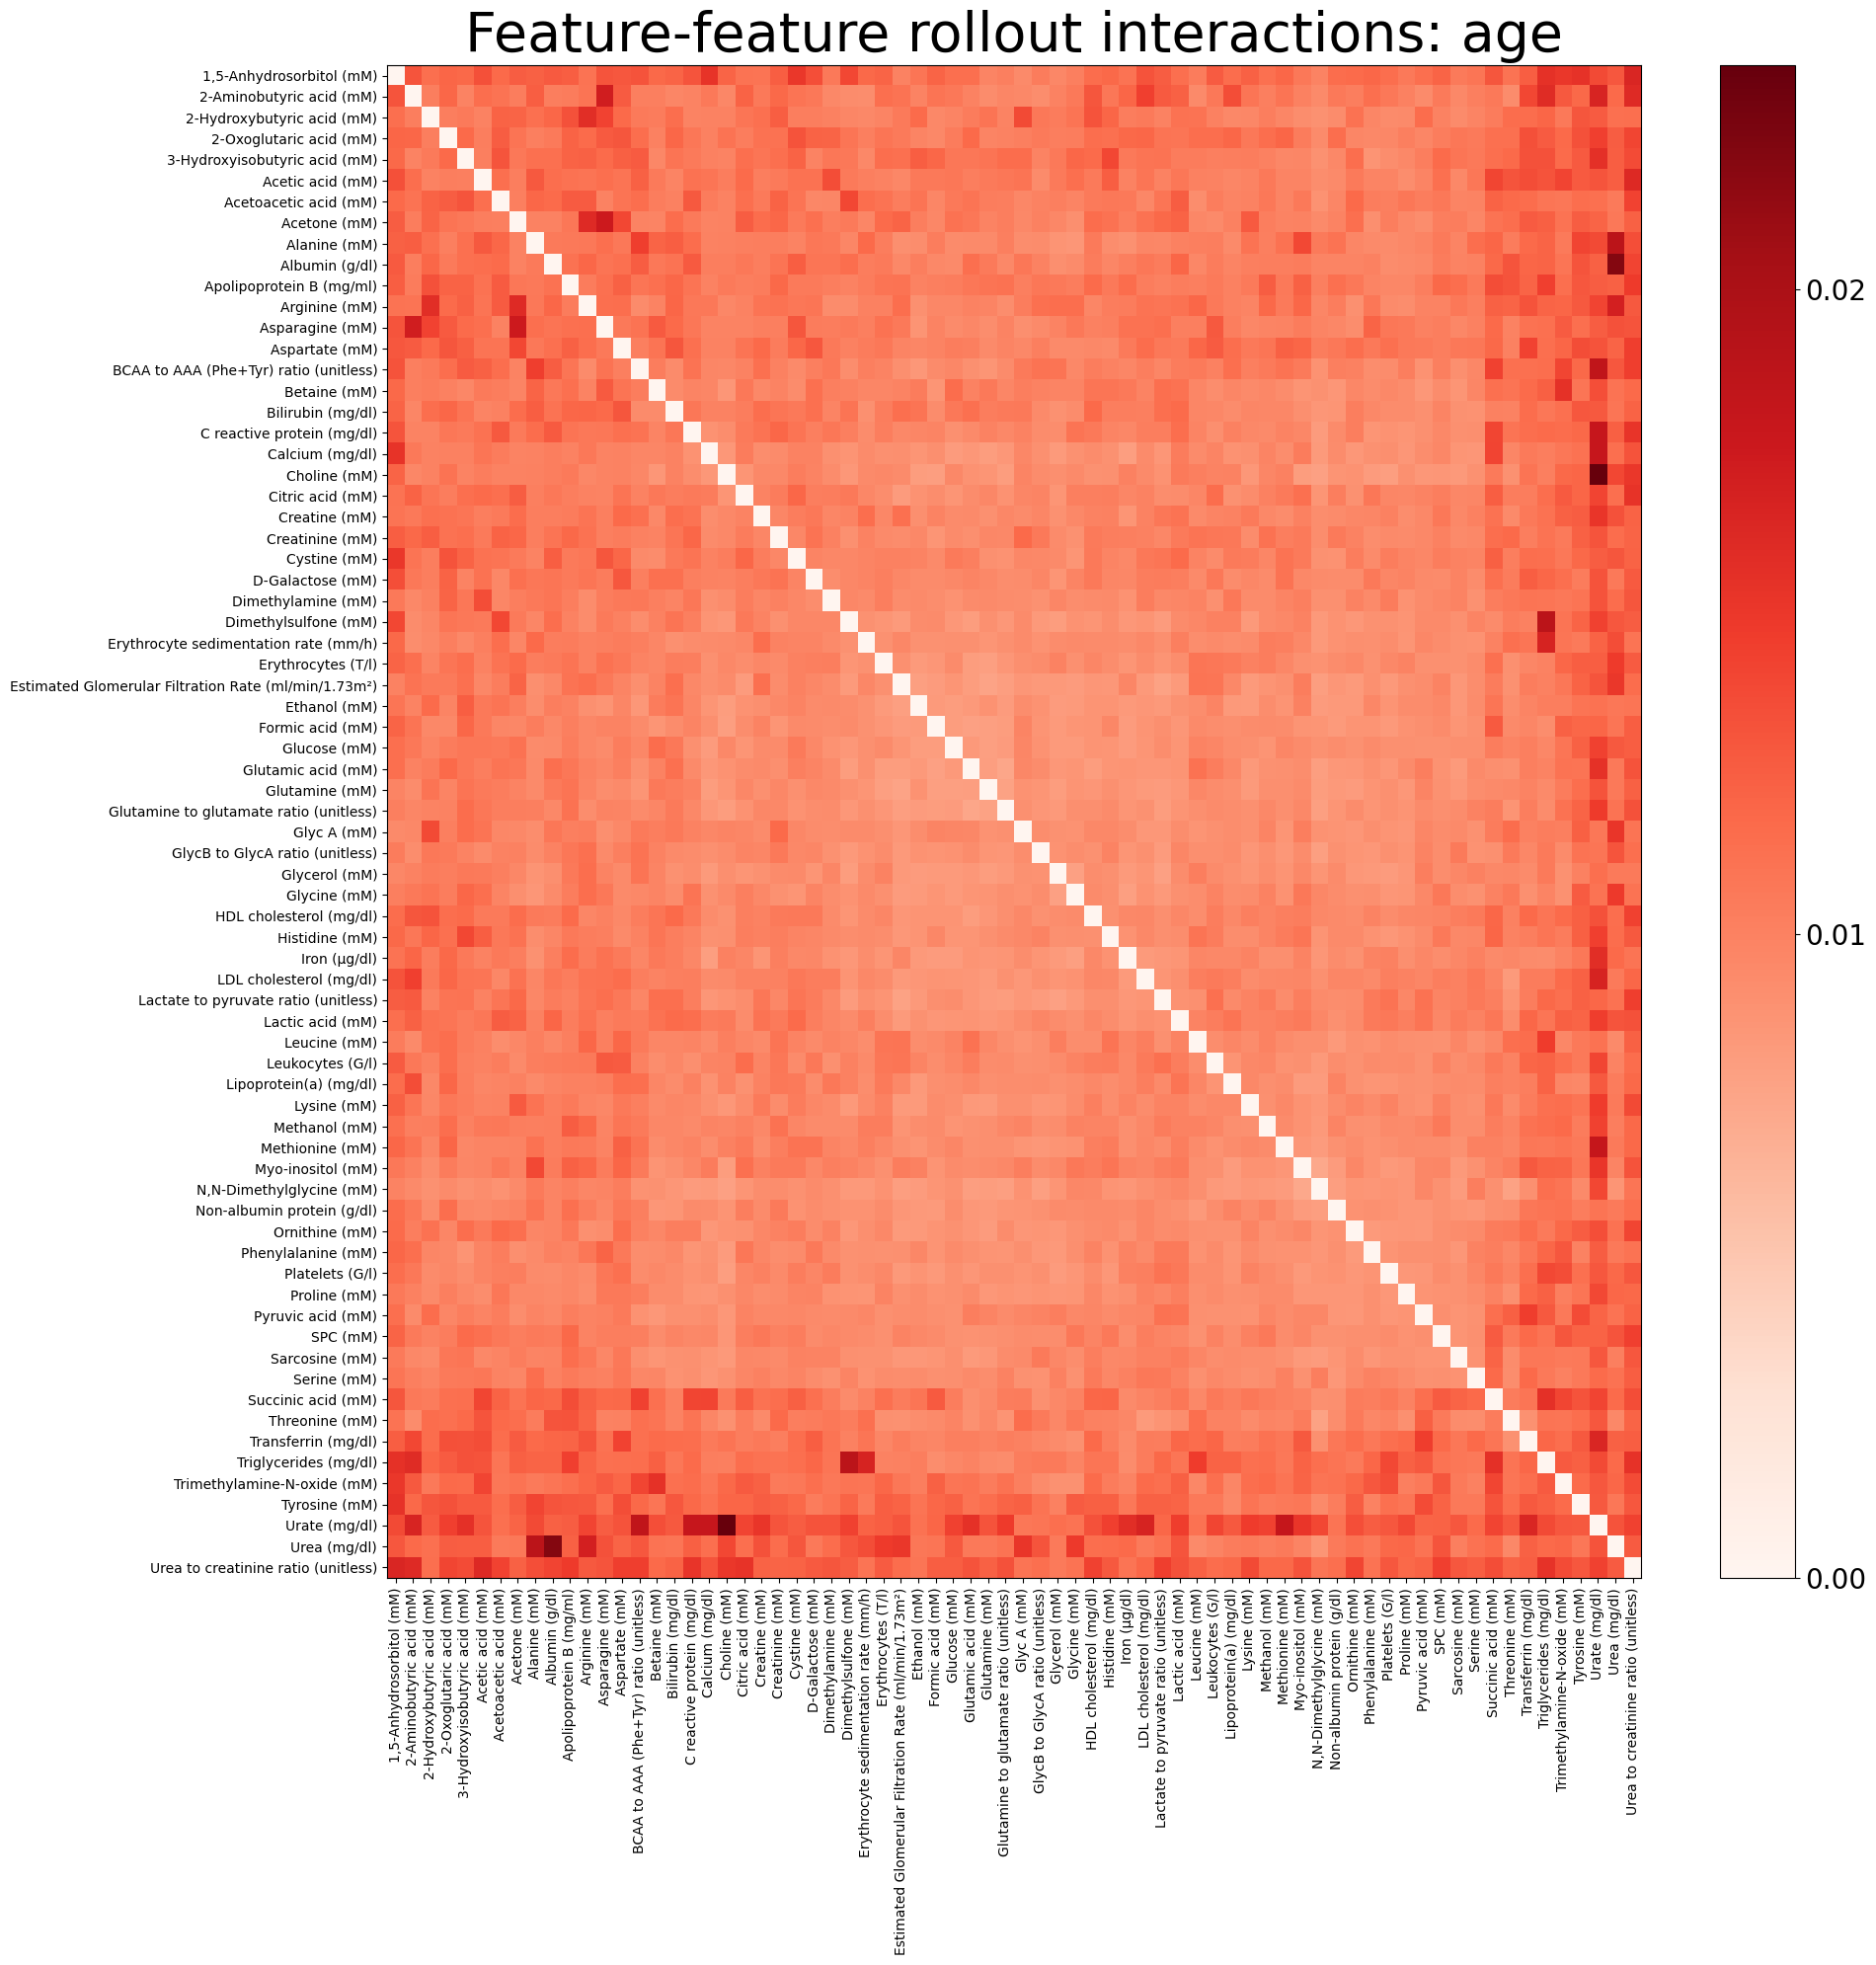

In [4]:
A = interactions.copy()
A = reorder_clustering(A)
    
VMIN = np.min(A) + 1e-8
VMAX = np.max(A)
plt.figure(figsize=(20, 20))
im = plt.imshow(A, aspect='auto', cmap=colormaps[type], 
                #norm=LogNorm(vmin=VMIN, vmax=VMAX)
               )

plt.title(f"Feature-feature rollout interactions: {type_names[type]}", fontsize=40, pad=10)

# ticks = np.linspace(VMIN, VMAX, 9)
# cbar = plt.colorbar(im, ticks=ticks)
# cbar.set_ticklabels([f"{t:.2f}" for t in ticks], fontsize=20)

ticks = {'age': [0, 0.01, 0.02, 0.03, 0.04],
         'mets': [0, 0.01, 0.02, 0.03, 0.04],
         'sex': [0, 0.01, 0.02, 0.03, 0.04]
        }
cbar = plt.colorbar(im, ticks=ticks[type])
cbar.set_ticklabels([f"{t:.2f}" for t in ticks[type]], fontsize=20)

plt.xticks(
    ticks=np.arange(len(feature_names)),
    labels=feature_names,
    rotation=90,
    fontsize=10
)

plt.yticks(
    ticks=np.arange(len(feature_names)),
    labels=feature_names,
    fontsize=10
)
plt.tight_layout()
# plt.savefig(f"FiguresPaper/attention_rollout/interactions_all_{type}.pdf", bbox_inches="tight")
plt.show()